Goal:
Optimize EV charging inside the parking window.

The EV must receive the required energy before departure.

Charging can be shifted inside the available parking duration.

This notebook introduces EV flexibility as optimization variables.

In [2]:
# ==========================================================
# Imports
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import linprog

In [3]:
# ==========================================================
# Load EV data
# ==========================================================

ev = pd.read_csv("../data/raw/ev_sessions.csv")

print("Number of sessions:", len(ev))

Number of sessions: 8530


Use the high-demand day again.

In [4]:
# ==========================================================
# Select representative day
# ==========================================================

DAY = 95

ev_day = ev[ev["day"] == DAY].copy()

print("Sessions:", len(ev_day))
print("Energy demand [kWh]:", ev_day["energy_kwh"].sum())

Sessions: 35
Energy demand [kWh]: 509.0


In [5]:
# ==========================================================
# Examine charging sessions
# ==========================================================

ev_day[
    [
        "connection_minute",
        "disconnection_minute",
        "energy_kwh"
    ]
].head(10)

,connection_minute,disconnection_minute,energy_kwh
2253,510,1045,23.0
2254,665,1146,26.0
2255,805,987,0.0
2256,510,916,14.0
2257,517,1093,34.0
2258,398,887,29.0
2259,519,942,33.0
2260,597,950,16.0
2261,539,1119,14.0
2262,517,729,8.0


Remove the zero session day

Define EV charging LP variables 

No PV
No BESS
Only EV smart charging
Objective: minimize charging cost using electricity price   || simple first 

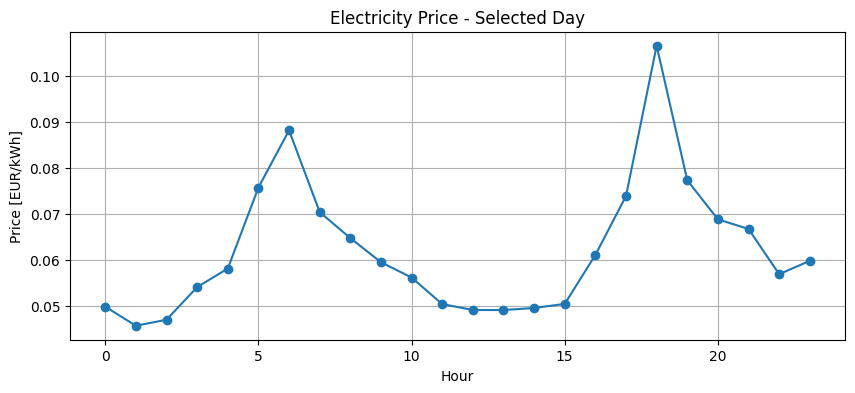

In [9]:
# ==========================================================
# Load electricity prices
#
# We use prices as the cost signal.
# The optimizer will prefer charging EVs during cheaper hours.
# ==========================================================

from scipy.io import loadmat

price_mat = loadmat("../data/raw/prices_yearly.mat")

price_year = price_mat["prices_all_year"].flatten()

price_day = price_year[
    (DAY - 1) * 24 : DAY * 24
]

hours = np.arange(24)

plt.figure(figsize=(10,4))
plt.plot(hours, price_day, marker="o")

plt.title("Electricity Price - Selected Day")
plt.xlabel("Hour")
plt.ylabel("Price [EUR/kWh]")
plt.grid()

plt.show()

In [10]:
# ==========================================================
# Remove sessions with zero required energy
#
# These EVs are connected, but they do not need charging.
# They do not affect the optimization.
# ==========================================================

ev_opt = ev_day[
    ev_day["energy_kwh"] > 0
].copy()

ev_opt = ev_opt.reset_index(drop=True)

n_ev = len(ev_opt)

print("EVs used in optimization:", n_ev)
print("Total energy [kWh]:", ev_opt["energy_kwh"].sum())

EVs used in optimization: 34
Total energy [kWh]: 509.0


In [ ]:
# ==========================================================
# EV CHARGING DECISION VARIABLES
# ==========================================================
#
# Decision variable:
#
# P_ev[i, h]
#
# Meaning:
# Charging power of EV i during hour h.
#
# Dimensions:
# number of EVs x 24 hours
#
# Flattened into one vector:
#
# x = [
#   P_ev[0,0], P_ev[0,1], ..., P_ev[0,23],
#   P_ev[1,0], P_ev[1,1], ..., P_ev[1,23],
#   ...
# ]
# ==========================================================

N = 24
dt = 1.0

P_charger_max = 7.0  # kW per EV charger

n_vars = n_ev * N

print("Number of variables:", n_vars)

Number of variables: 816


34 EVs used ||
509 kWh total demand ||
816 variables = 34 EVs × 24 hours

One EV had energy_kwh = 0, so we removed it

Objective Vector

In [13]:
# ==========================================================
# OBJECTIVE FUNCTION
# ==========================================================
#
# Minimize total EV charging cost:
#
# sum over all EVs and all hours:
#
#     price[h] * P_ev[i,h] * dt
#
# Since dt = 1 hour, power [kW] and energy [kWh]
# have the same numeric value per time step.
# ==========================================================

c = np.zeros(n_vars)

for i in range(n_ev):
    for h in range(N):

        var_index = i * N + h

        c[var_index] = price_day[h] * dt

Equality Constraints

In [14]:
# ==========================================================
# EQUALITY CONSTRAINTS
# ==========================================================
#
# Each EV must receive its required energy before departure.
#
# For each EV i:
#
# sum_h P_ev[i,h] * dt = energy_required_i
#
# This guarantees that every vehicle leaves with the requested
# amount of energy.
# ==========================================================

A_eq = []
b_eq = []

for i in range(n_ev):

    row = np.zeros(n_vars)

    for h in range(N):

        var_index = i * N + h

        row[var_index] = dt

    A_eq.append(row)

    b_eq.append(ev_opt.loc[i, "energy_kwh"])

A_eq = np.array(A_eq)
b_eq = np.array(b_eq)

print("A_eq shape:", A_eq.shape)
print("b_eq shape:", b_eq.shape)

A_eq shape: (34, 816)
b_eq shape: (34,)


Bounds with parking windows

In [15]:
# ==========================================================
# VARIABLE BOUNDS
# ==========================================================
#
# Bounds enforce the parking window.
#
# If EV i is connected during hour h:
#
#     0 <= P_ev[i,h] <= P_charger_max
#
# If EV i is NOT connected during hour h:
#
#     P_ev[i,h] = 0
#
# This is how we force the optimizer to charge only while
# the vehicle is physically parked.
# ==========================================================

bounds = []

for i in range(n_ev):

    connection_minute = ev_opt.loc[i, "connection_minute"]
    disconnection_minute = ev_opt.loc[i, "disconnection_minute"]

    for h in range(N):

        hour_start = h * 60
        hour_end = (h + 1) * 60

        # Check if this hour overlaps with the EV parking window
        overlap_min = max(
            0,
            min(disconnection_minute, hour_end)
            - max(connection_minute, hour_start)
        )

        if overlap_min > 0:

            # EV is connected during this hour.
            # For simplicity we allow up to full charger power.
            bounds.append((0, P_charger_max))

        else:

            # EV is not connected.
            # Charging power must be exactly zero.
            bounds.append((0, 0))

print("Number of bounds:", len(bounds))

Number of bounds: 816


Solve LP

In [16]:
# ==========================================================
# SOLVE EV SMART CHARGING LP
# ==========================================================
#
# The LP chooses when each EV should charge.
#
# It minimizes electricity cost while respecting:
#
# - EV connection time
# - EV disconnection time
# - required charging energy
# - charger power limit
# ==========================================================

result = linprog(
    c=c,
    A_eq=A_eq,
    b_eq=b_eq,
    bounds=bounds,
    method="highs"
)

print("Solver success:", result.success)
print("Solver message:", result.message)
print("Optimal EV charging cost [EUR]:", result.fun)

Solver success: True
Solver message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimal EV charging cost [EUR]: 25.260780000000015


Extract optimized charging profile 

In [17]:
# ==========================================================
# EXTRACT OPTIMAL EV CHARGING PROFILE
# ==========================================================

x_opt = result.x

P_ev_opt = x_opt.reshape(
    n_ev,
    N
)

ev_smart_profile = P_ev_opt.sum(axis=0)

print("Optimized EV energy [kWh]:", ev_smart_profile.sum())
print("Required EV energy [kWh]:", ev_opt["energy_kwh"].sum())
print("Peak optimized EV power [kW]:", ev_smart_profile.max())

Optimized EV energy [kWh]: 509.0
Required EV energy [kWh]: 509.0
Peak optimized EV power [kW]: 204.0


Compare ASAP vs smart charging

In [18]:
# ==========================================================
# Build ASAP profile again for comparison
# ==========================================================

ev_asap = np.zeros(N)

for _, car in ev_opt.iterrows():

    energy_remaining = car["energy_kwh"]

    start_min = int(car["connection_minute"])
    end_min = int(car["full_minute"])

    for h in range(N):

        hour_start = h * 60
        hour_end = (h + 1) * 60

        overlap_min = max(
            0,
            min(end_min, hour_end) - max(start_min, hour_start)
        )

        if overlap_min > 0:

            energy_this_hour = P_charger_max * overlap_min / 60

            energy_this_hour = min(
                energy_this_hour,
                energy_remaining
            )

            ev_asap[h] += energy_this_hour

            energy_remaining -= energy_this_hour

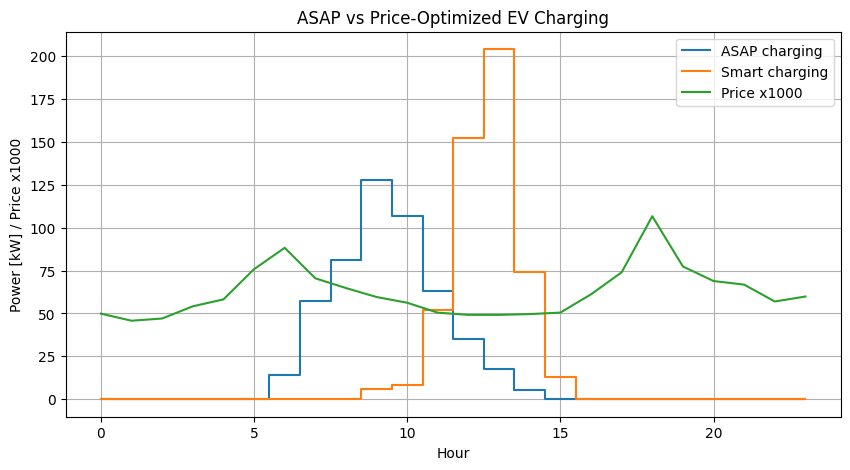

In [19]:
# ==========================================================
# PLOT ASAP VS SMART EV CHARGING
# ==========================================================

plt.figure(figsize=(10,5))

plt.step(hours, ev_asap, where="mid", label="ASAP charging")
plt.step(hours, ev_smart_profile, where="mid", label="Smart charging")
plt.plot(hours, price_day * 1000, label="Price x1000")

plt.xlabel("Hour")
plt.ylabel("Power [kW] / Price x1000")
plt.title("ASAP vs Price-Optimized EV Charging")
plt.grid()
plt.legend()

plt.show()

Cost minimization alone creates new peaks.